
# Multi-Scale Wiener and Patched Loss for Autoencoder Reconstruction

This notebook trains a simple Autoencoder on the MNIST dataset using:
1. **Wiener Loss**
2. **Multi-Scale Wiener Loss (MSWienerLoss)**
3. **Patched Wiener Loss**
4. **Mean Squared Error**

We compare their reconstruction performance both quantitatively and qualitatively.


In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

from wiener_loss import WienerLoss, MSWienerLoss, PatchWienerLoss
from utils import set_seed

In [11]:

# Data preparation
transform = transforms.Compose([
    transforms.ToTensor(), 
    # transforms.Grayscale(num_output_channels=1)
])

# train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# subset of MNIST for fast prototyping
train_dataset.data = train_dataset.data[:1000]
test_dataset.data = test_dataset.data[:1000]

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)


Files already downloaded and verified
Files already downloaded and verified


In [12]:

# Small Autoencoder Model
class Autoencoder(nn.Module):
    def __init__(self, in_channels=1):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, in_channels, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
    

# test model output shape
model = Autoencoder(in_channels=train_dataset[0][0].shape[0])
x = torch.randn_like(train_dataset[0][0].unsqueeze(0))  # Example input
output = model(x)
print("Output shape:", output.shape)  
assert output.shape == x.shape, "Output shape does not match input shape!"

Output shape: torch.Size([1, 3, 32, 32])


In [13]:

# Training function for reconstruction
def train_reconstruction(model, loss_fn, optimizer, loader, penalty_optim=None, device='cpu', **kwargs):
    model.train()
    total_loss = 0
    for data, _ in loader:
        data = data.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, data, **kwargs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # Update penalty optimizer if provided
        if penalty_optim is not None:
            penalty_optim.zero_grad()
            loss.backward()
            penalty_optim.step()

    return total_loss / len(loader)


  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [01:09<00:00, 10.00s/it]


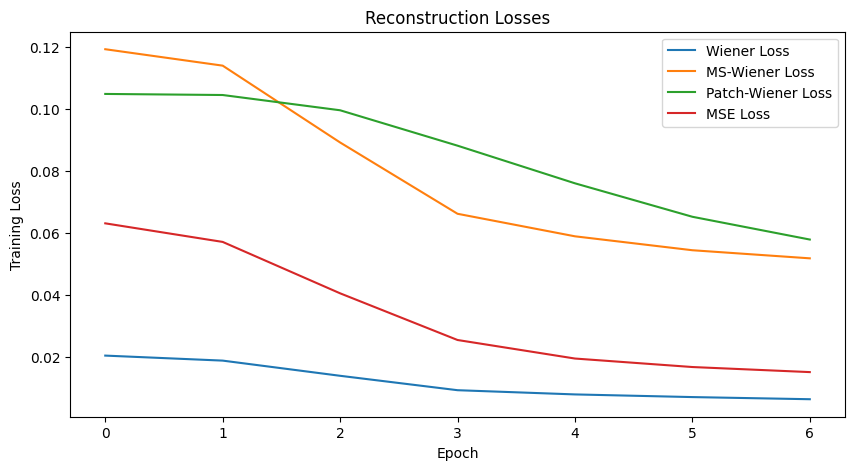

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
in_channels = train_dataset[0][0].shape[0]  # Number of channels in the input data

set_seed(42)
model_wiener = Autoencoder(in_channels=in_channels).to(device)
model_mswiener = Autoencoder(in_channels=in_channels).to(device)
model_patchwiener = Autoencoder(in_channels=in_channels).to(device)
model_mse = Autoencoder(in_channels=in_channels).to(device)

def pfn(mesh):
    return torch.zeros_like(mesh[..., -1]) + 1.

# Initialize WienerLoss and MSWienerLoss
wiener_loss = WienerLoss(input_shape=(1, 28, 28), lmbda=1e-4, store_filters=True, penalty_function=pfn, filter_scale=5.)
ms_wiener_loss = MSWienerLoss(scales=3, input_shape=(1, 28, 28), lmbda=1e-4, store_filters=True, penalty_function=pfn)
patch_wiener_loss = PatchWienerLoss(input_shape=(1, 28, 28), lmbda=1e-4, store_filters=True, global_weight=0.5, penalty_function=pfn, patch_size=(8, 8), stride=(4, 4))
mse_loss = nn.MSELoss()

optimizer_wiener_penalty = optimizer_mswiener_penalty = optimizer_patchwiener_penalty = None
# if wiener_loss.penalty_function == "trainable":
#     wiener_loss.to(device)
#     optimizer_wiener_penalty = optim.Adam(wiener_loss.parameters(), lr=0.001)
# if ms_wiener_loss.wiener_losses[0].penalty_function == "trainable":
#     ms_wiener_loss.to(device)
#     optimizer_mswiener_penalty = optim.Adam([ms_wiener_loss.wiener_losses[i].parameters() for i in range(ms_wiener_loss.scales)], lr=0.001)

optimizer_wiener = optim.Adam(model_wiener.parameters(), lr=0.001)
optimizer_mswiener = optim.Adam(model_mswiener.parameters(), lr=0.001)
optimizer_patchwiener = optim.Adam(model_patchwiener.parameters(), lr=0.001)
optimizer_mse = optim.Adam(model_mse.parameters(), lr=0.001)

epochs = 7
train_losses_wiener = []
train_losses_mswiener = []
train_losses_patchwiener = []
train_losses_mse = []

for epoch in tqdm(range(epochs)):
    loss_wiener = train_reconstruction(model_wiener, wiener_loss, optimizer_wiener, train_loader, optimizer_wiener_penalty, device, gamma=0.1)
    loss_mswiener = train_reconstruction(model_mswiener, ms_wiener_loss, optimizer_mswiener, train_loader, optimizer_mswiener_penalty, device, gamma=0.1)
    loss_patchwiener = train_reconstruction(model_patchwiener, patch_wiener_loss, optimizer_patchwiener, train_loader, optimizer_patchwiener_penalty, device, gamma=0.1)
    loss_mse = train_reconstruction(model_mse, mse_loss, optimizer_mse, train_loader, None, device)

    train_losses_wiener.append(loss_wiener)
    train_losses_mswiener.append(loss_mswiener)
    train_losses_patchwiener.append(loss_patchwiener)
    train_losses_mse.append(loss_mse)
    

# Plot training losses
plt.figure(figsize=(10,5))
plt.plot(train_losses_wiener, label='Wiener Loss')
plt.plot(train_losses_mswiener, label='MS-Wiener Loss')
plt.plot(train_losses_patchwiener, label='Patch-Wiener Loss')
plt.plot(train_losses_mse, label='MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Reconstruction Losses')
plt.legend()
plt.show()



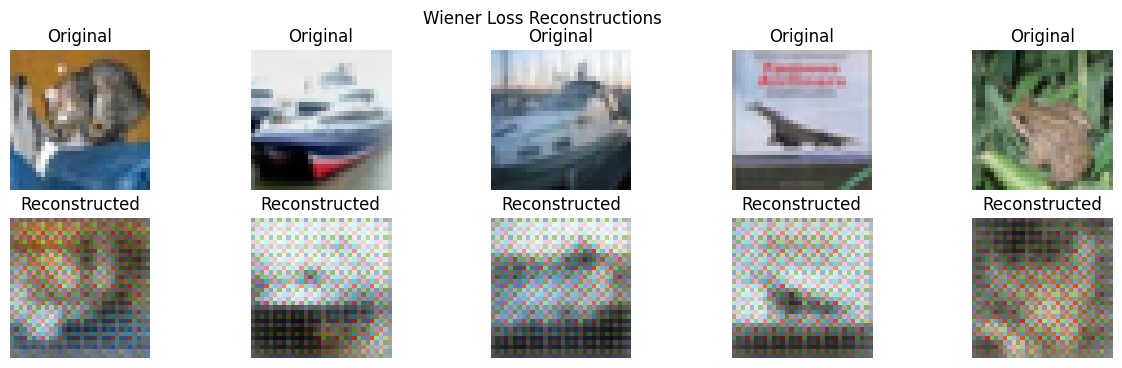

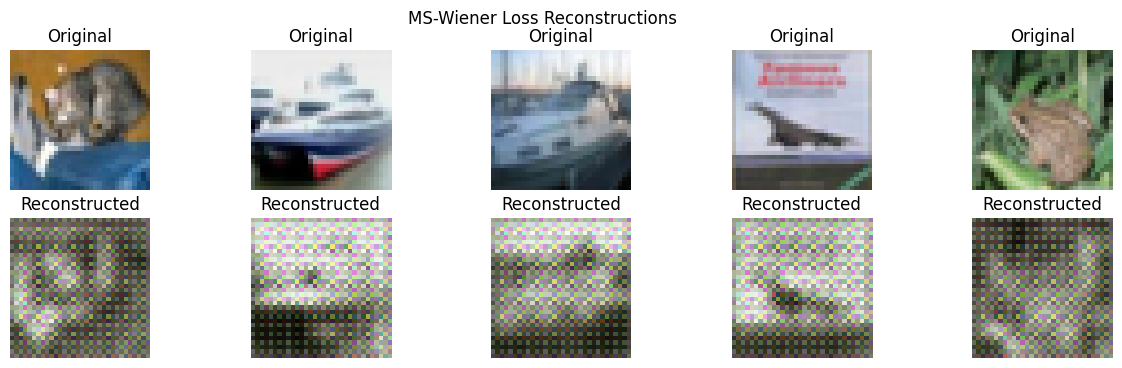

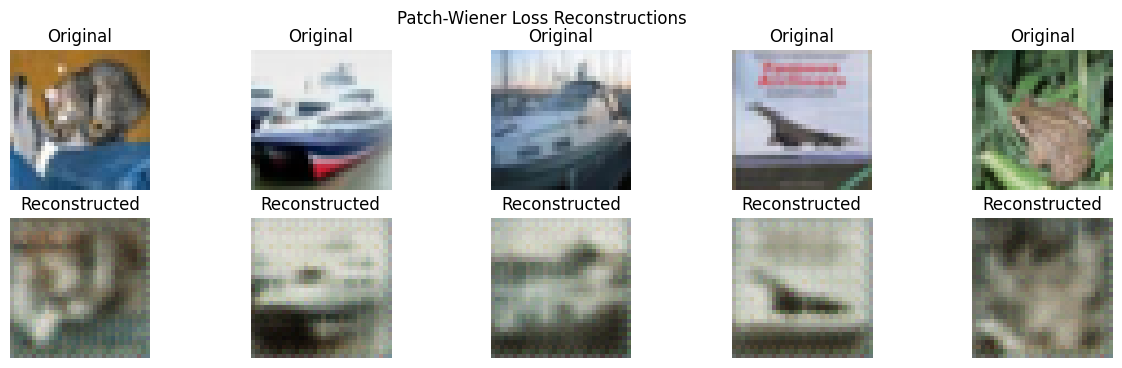

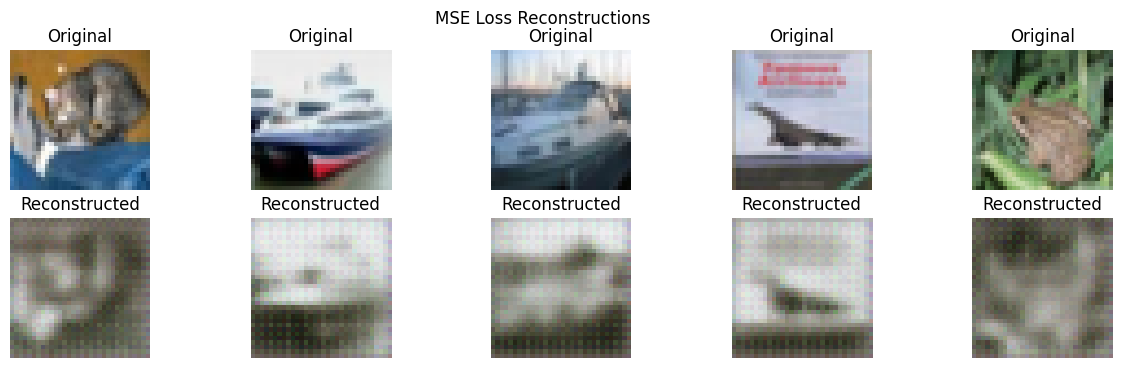

In [18]:
# Visualise model reconstructions
def visualize_reconstructions(model, loader, device, num_images=5, title='Reconstruction'):
    model.eval()
    data_iter = iter(loader)
    images, _ = next(data_iter)
    images = images.to(device)
    
    with torch.no_grad():
        outputs = model(images)
    
    fig, axes = plt.subplots(2, num_images, figsize=(15, 4))
    for i in range(num_images):
        axes[0, i].imshow(images[i].permute(1, 2, 0).cpu().squeeze(), cmap='gray')
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')

        axes[1, i].imshow(outputs[i].permute(1, 2, 0).cpu().squeeze(), cmap='gray')
        axes[1, i].set_title("Reconstructed")
        axes[1, i].axis('off')
    
    plt.suptitle(title)
    plt.show()

# Visualize reconstructions for both models
visualize_reconstructions(model_wiener, test_loader, device, title='Wiener Loss Reconstructions')
visualize_reconstructions(model_mswiener, test_loader, device, title='MS-Wiener Loss Reconstructions')
visualize_reconstructions(model_patchwiener, test_loader, device, title='Patch-Wiener Loss Reconstructions')
visualize_reconstructions(model_mse, test_loader, device, title='MSE Loss Reconstructions')

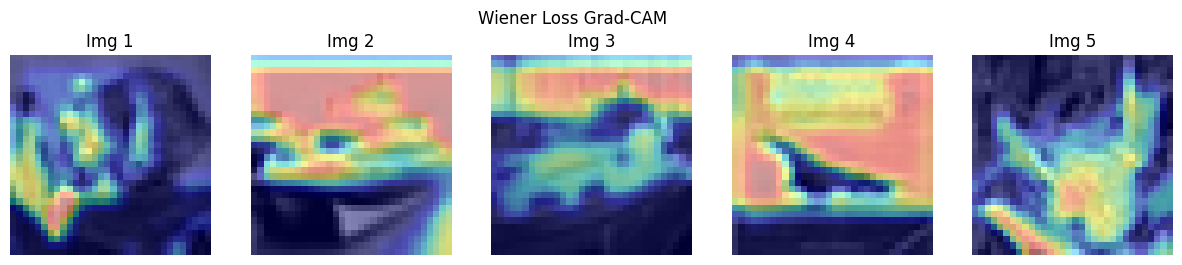

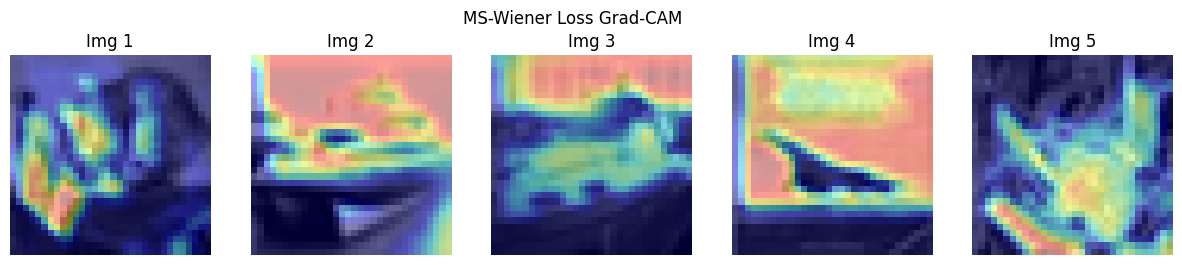

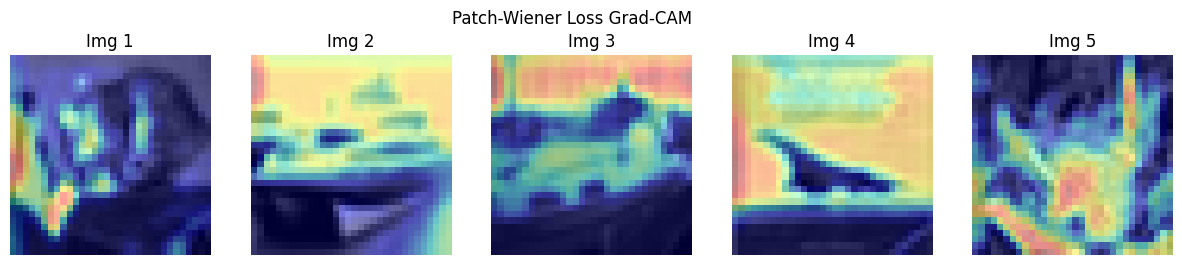

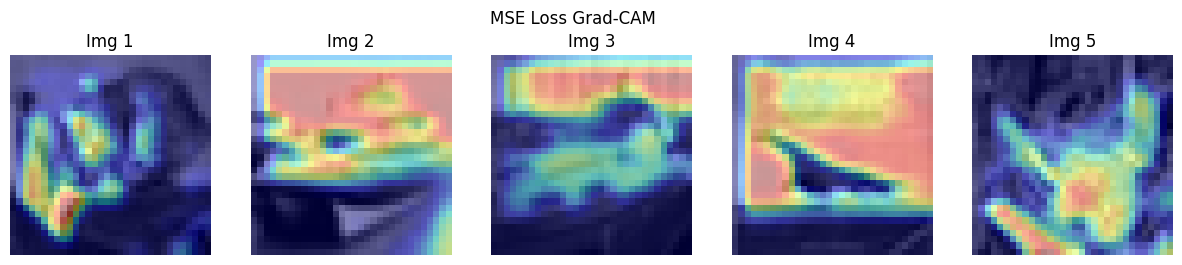

In [25]:
def compute_gradcam(model, input_image, target_layer):
    model.eval()
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])
    
    def forward_hook(module, input, output):
        activations.append(output)
    
    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_backward_hook(backward_hook)
    
    input_image = input_image.unsqueeze(0).to(next(model.parameters()).device).requires_grad_(True)
    output = model(input_image)
    loss = output.sum()
    model.zero_grad()
    loss.backward()
    
    grads = gradients[0].cpu().data
    acts = activations[0].cpu().data
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, size=input_image.shape[-2:], mode='bilinear', align_corners=False)
    cam = cam.squeeze().numpy()
    
    handle_f.remove()
    handle_b.remove()
    
    return cam

def plot_gradcam_batch(model, loader, target_layer, device, title="Grad-CAM", num_images=5):
    """
    Plots Grad-CAM for multiple images in a batch.

    Args:
        model: PyTorch model.
        loader: DataLoader.
        target_layer: Layer to compute Grad-CAM on.
        device: torch.device.
        title: Title for the figure.
        num_images: Number of images to plot from the batch.
    """
    data_iter = iter(loader)
    images, _ = next(data_iter)
    images = images.to(device)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    
    for idx in range(num_images):
        image = images[idx]
        cam = compute_gradcam(model, image, target_layer)

        axes[idx].imshow(image.cpu().squeeze()[0], cmap='gray')
        axes[idx].imshow(cam, cmap='jet', alpha=0.4)
        axes[idx].set_title(f"Img {idx+1}")
        axes[idx].axis('off')
    
    plt.suptitle(title)
    plt.show()

# Plot Grad-CAM for both models using the first conv layer in encoder
plot_gradcam_batch(model_wiener, test_loader, model_wiener.encoder[0], device, title="Wiener Loss Grad-CAM")
plot_gradcam_batch(model_mswiener, test_loader, model_mswiener.encoder[0], device, title="MS-Wiener Loss Grad-CAM")
plot_gradcam_batch(model_patchwiener, test_loader, model_patchwiener.encoder[0], device, title="Patch-Wiener Loss Grad-CAM")
plot_gradcam_batch(model_mse, test_loader, model_mse.encoder[0], device, title="MSE Loss Grad-CAM")


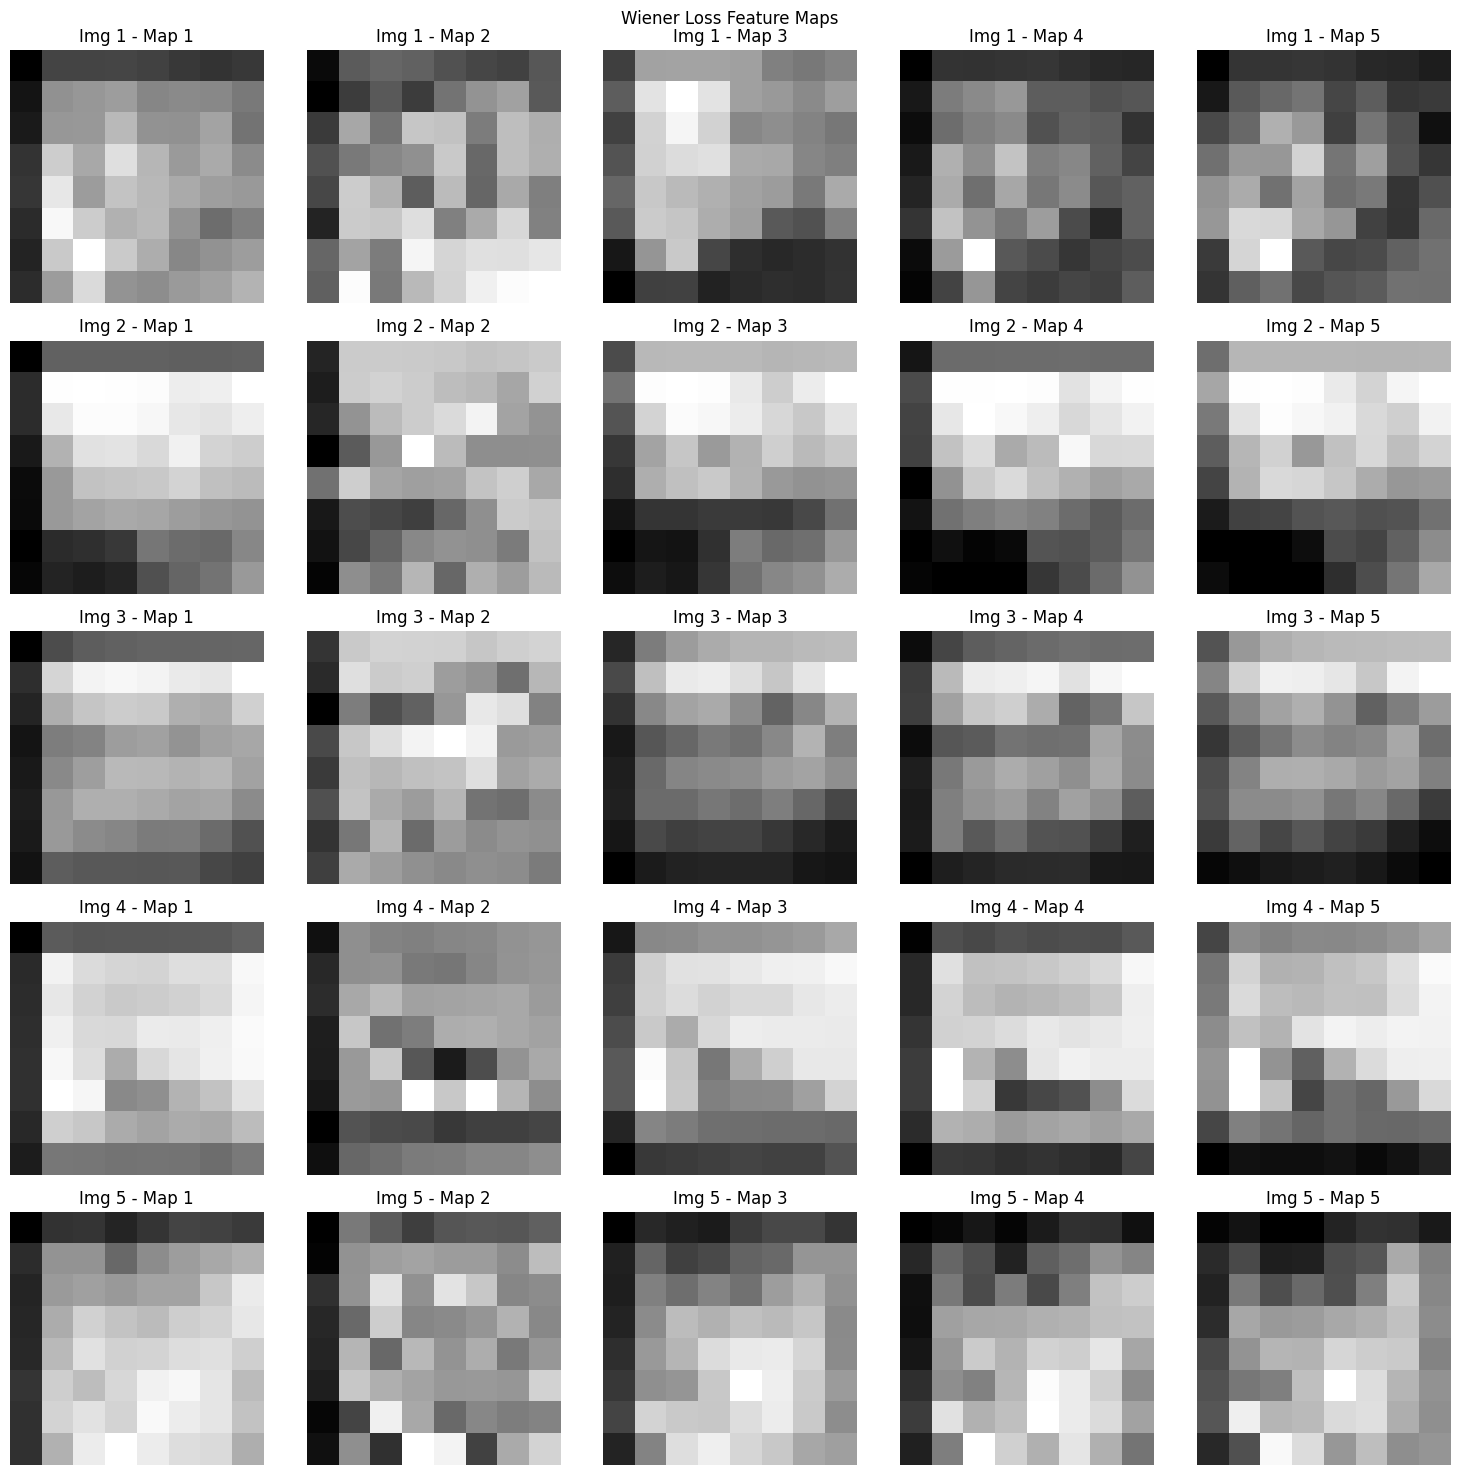

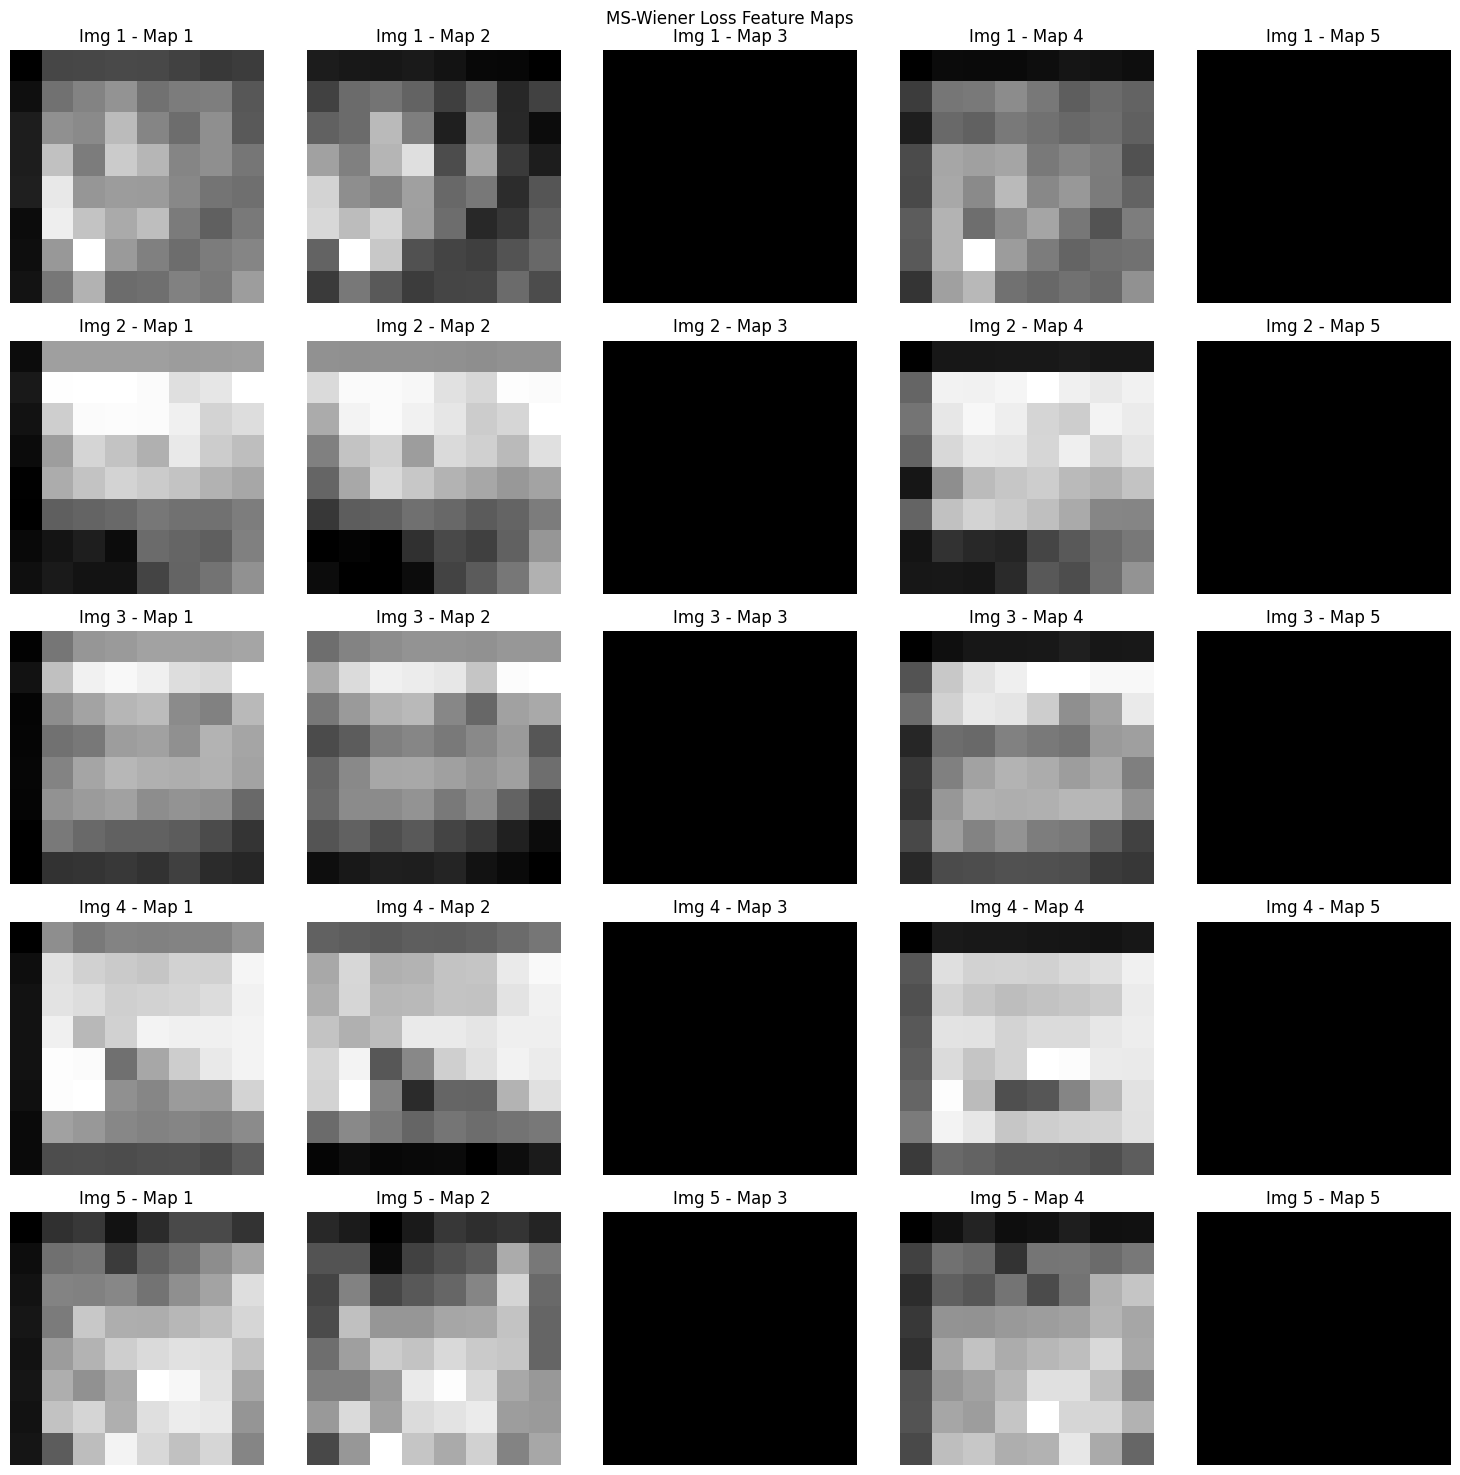

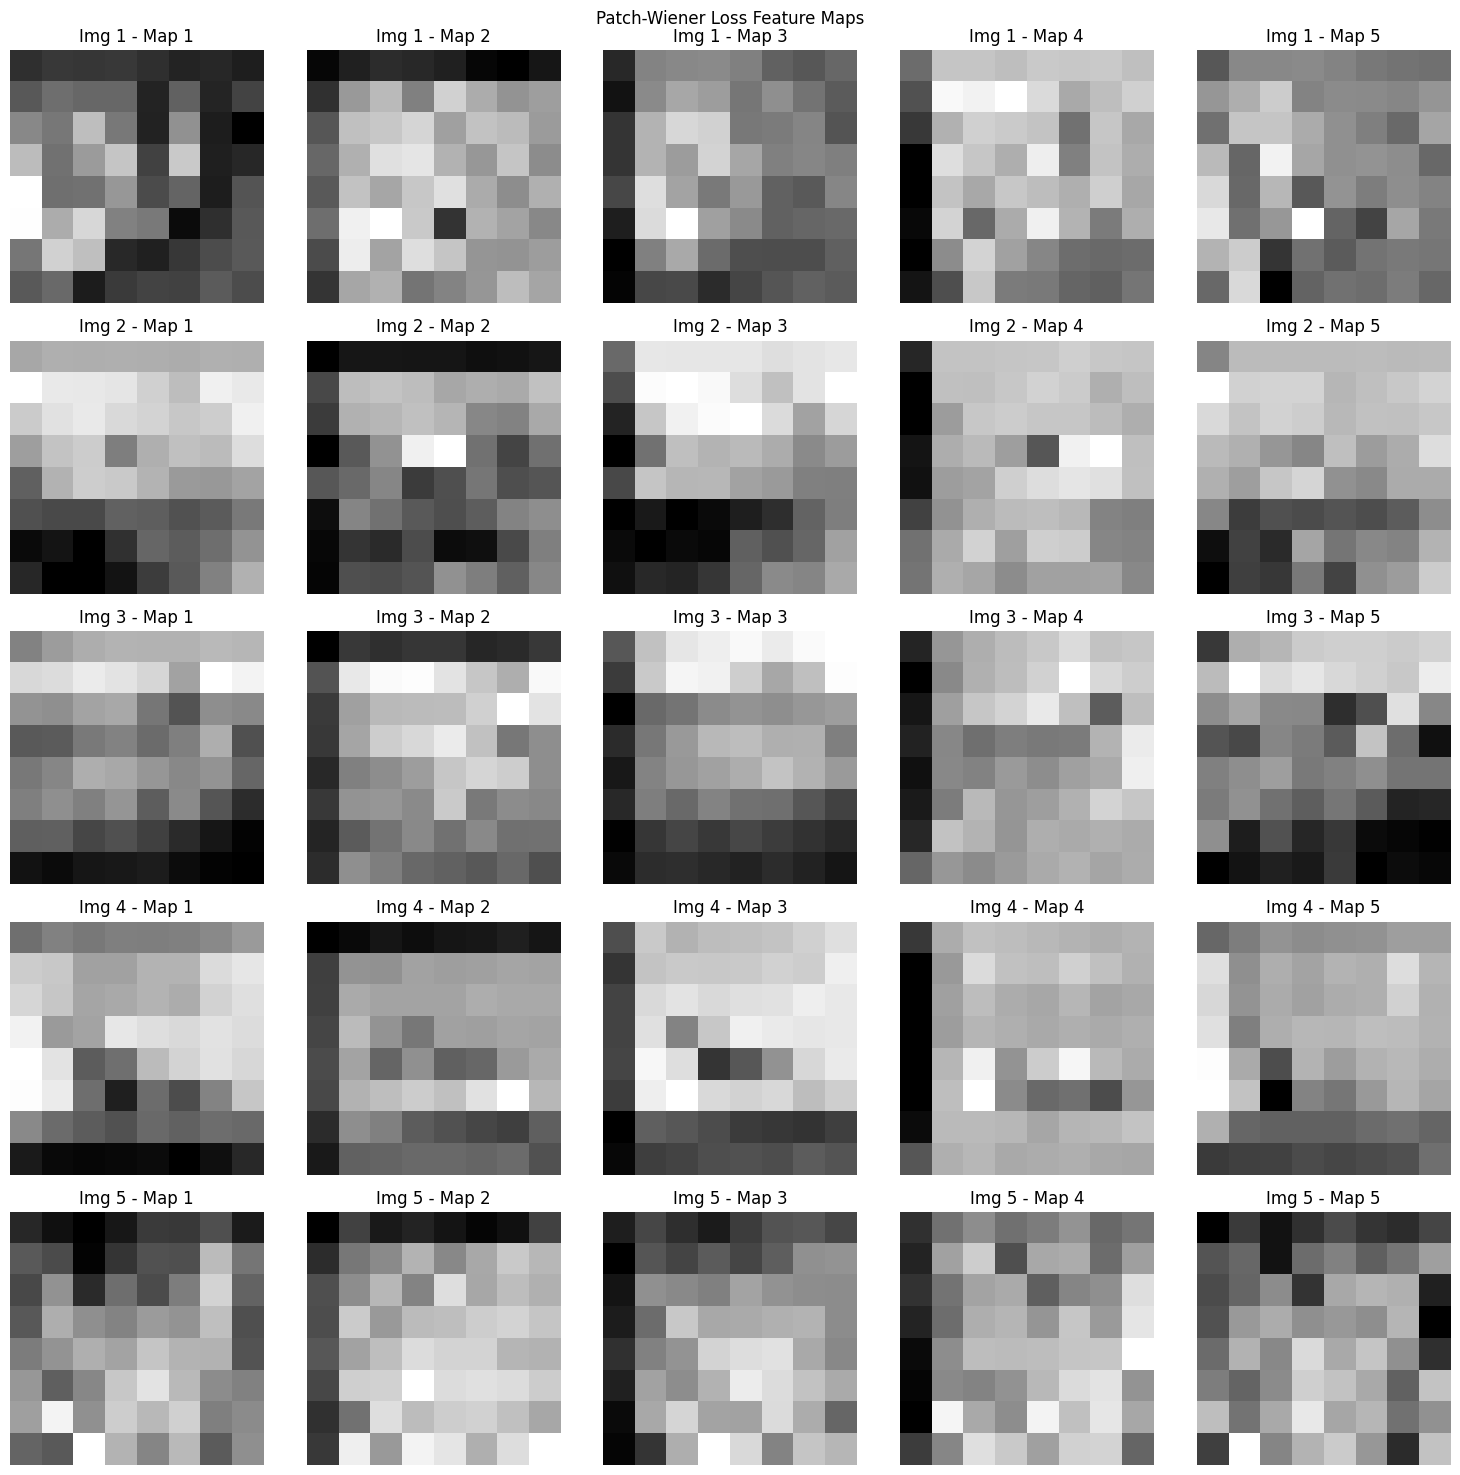

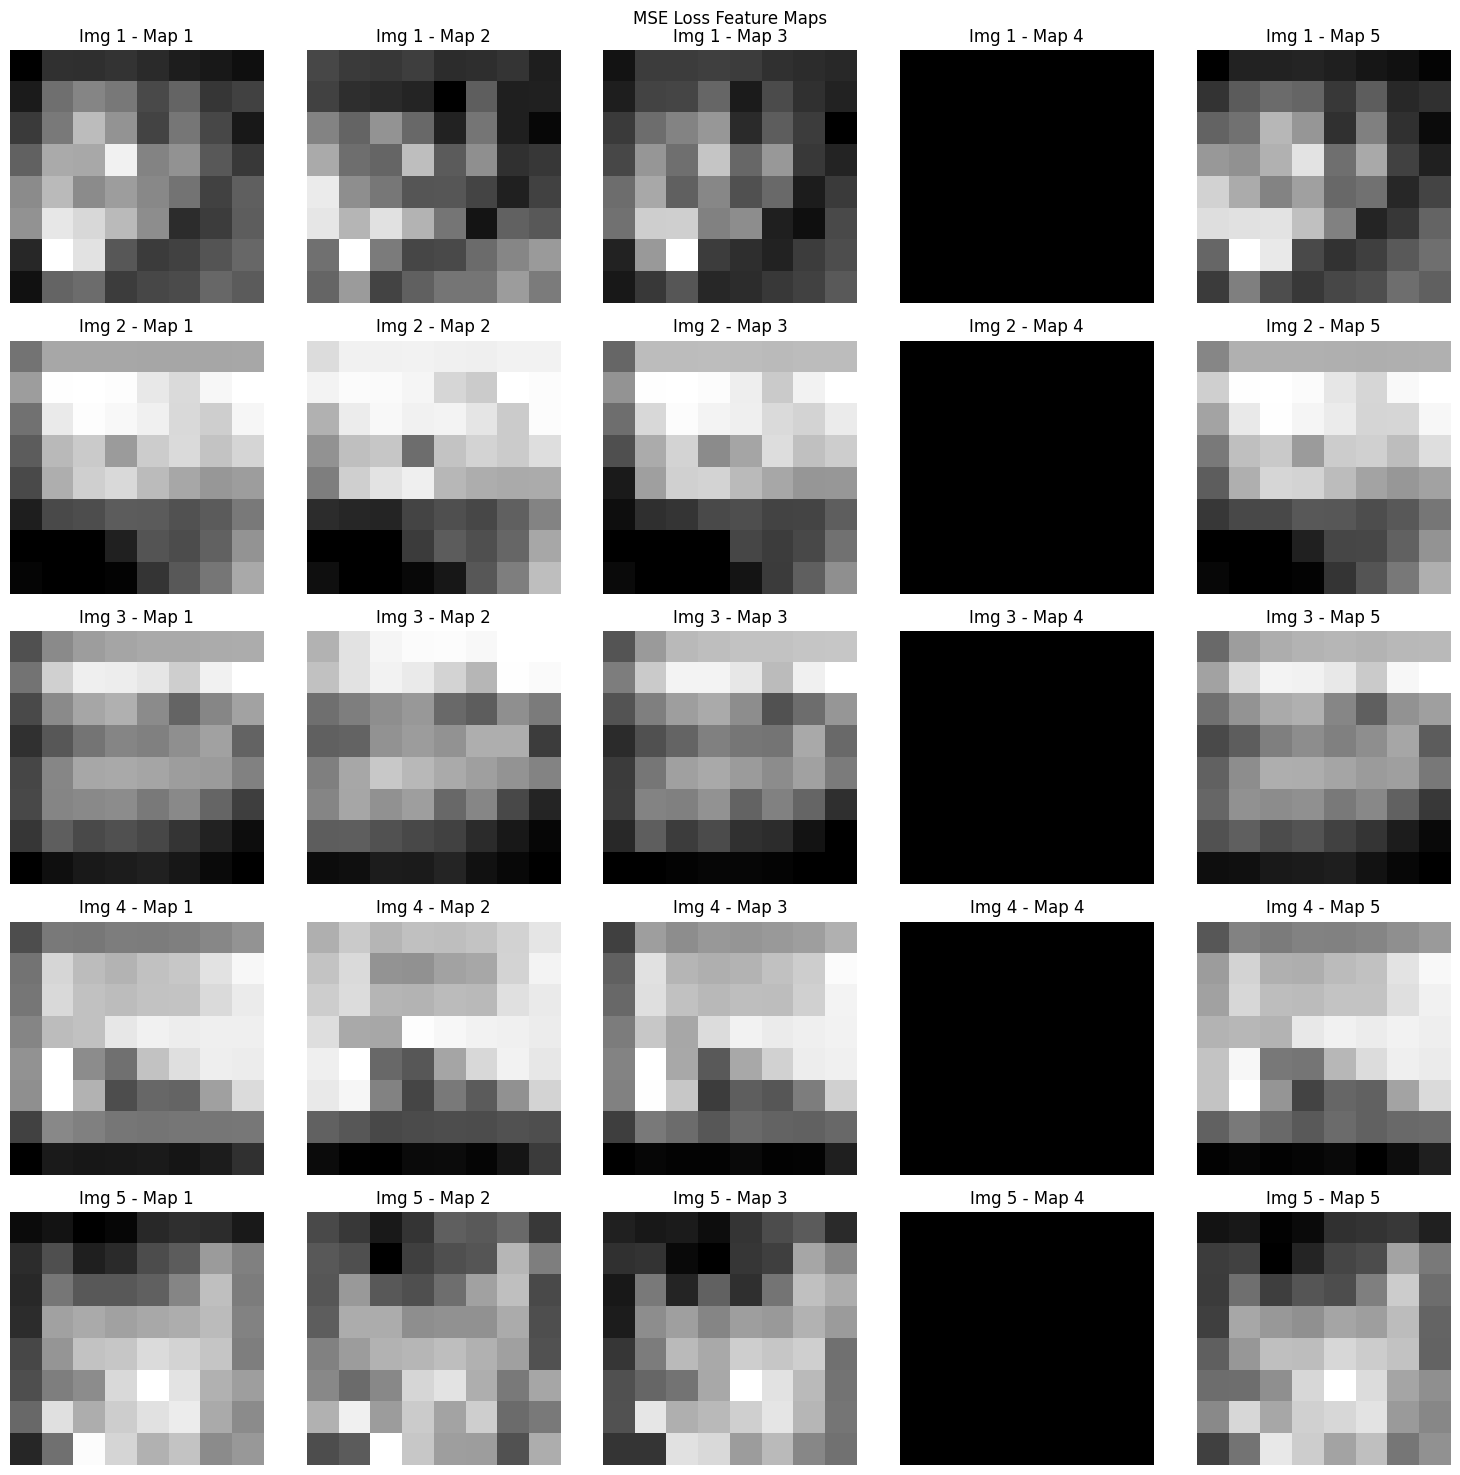

In [26]:
def plot_feature_maps_batch(model, loader, device, num_maps=5, num_images=5, title='Feature Maps'):
    """
    Plots feature maps for multiple images in a batch.

    Args:
        model: PyTorch model.
        loader: DataLoader.
        device: torch.device.
        num_maps: Number of feature maps to plot per image.
        num_images: Number of images from the batch to plot.
        title: Title for the figure.
    """
    data_iter = iter(loader)
    images, _ = next(data_iter)
    images = images.to(device)

    model.eval()
    with torch.no_grad():
        features = model.encoder(images)
    
    fig, axes = plt.subplots(num_images, num_maps, figsize=(3*num_maps, 3*num_images))

    for img_idx in range(num_images):
        for map_idx in range(num_maps):
            ax = axes[img_idx, map_idx] if num_images > 1 else axes[map_idx]
            ax.imshow(features[img_idx, map_idx].cpu().numpy(), cmap='gray')
            ax.set_title(f"Img {img_idx+1} - Map {map_idx+1}")
            ax.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Plot feature maps for both models
plot_feature_maps_batch(model_wiener, test_loader, device, title="Wiener Loss Feature Maps")
plot_feature_maps_batch(model_mswiener, test_loader, device, title="MS-Wiener Loss Feature Maps")
plot_feature_maps_batch(model_patchwiener, test_loader, device, title="Patch-Wiener Loss Feature Maps")
plot_feature_maps_batch(model_mse, test_loader, device, title="MSE Loss Feature Maps")


Angle between x_dir and y_dir: 89.99 °


15it [00:48,  3.27s/it]


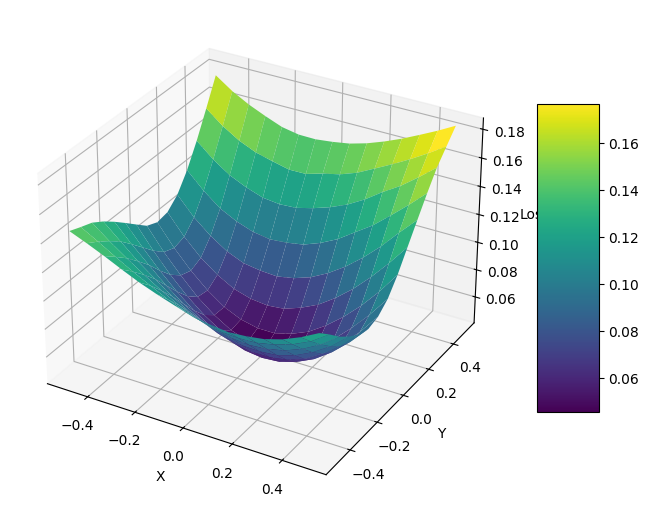

Angle between x_dir and y_dir: 90.00 °


15it [01:11,  4.75s/it]


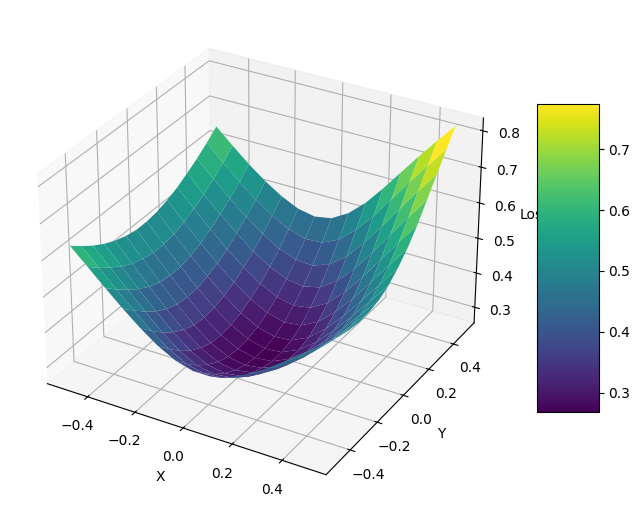

Angle between x_dir and y_dir: 89.95 °


15it [00:33,  2.26s/it]


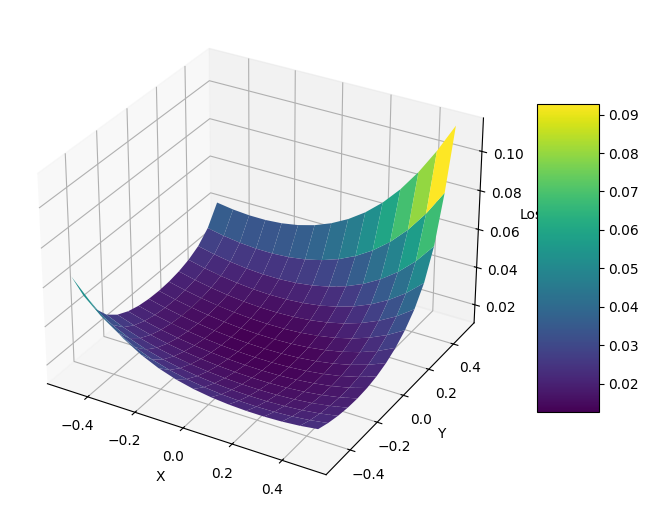

In [ ]:
# import from ./landscape
from landscape import visualise_landscape

_ = visualise_landscape(model_wiener, train_loader, wiener_loss, nx=15, ny=15, device=device)

_ = visualise_landscape(model_mswiener, train_loader, ms_wiener_loss, nx=15, ny=15, device=device)

_ = visualise_landscape(model_patchwiener, train_loader, patch_wiener_loss, nx=15, ny=15, device=device)

_ = visualise_landscape(model_mse, train_loader, mse_loss, nx=15, ny=15, device=device)
